# 1. 降雨数据获取示例

本教程将演示如何从 Google Earth Engine (GEE) 获取降雨数据，包括：
- **GFS (Global Forecast System)**: 全球天气预报系统数据
- **MSWEP (Multi-Source Weighted-Ensemble Precipitation)**: 多源加权集合降雨数据

## 数据获取思路

### 1. 流域准备
- 读取流域 shapefile 文件（包含 5819 个流域）
- 选择示例流域进行数据下载演示（BASIN_ID: songliao_21401550）
- 确定时间范围（示例：2024年全年）

### 2. GEE 数据访问
Google Earth Engine 是一个强大的地理空间分析平台，提供海量卫星和气象数据集：
- **GFS 数据集**: `NOAA/GFS0P25` - 0.25度分辨率的全球预报数据
- **MSWEP 数据集**: `PRINCETON/MSWEP/V280` 或类似数据集
- 需要使用 `earthengine-api` Python 库进行访问

### 3. 数据下载流程
1. **初始化 GEE**: 进行身份认证
2. **定义空间范围**: 使用流域边界（geometry）
3. **定义时间范围**: 设置开始和结束日期
4. **选择数据集**: GFS 或 MSWEP
5. **过滤和裁剪**: 按时间和空间过滤数据
6. **导出数据**: 下载到本地或 Google Drive

### 4. 数据存储
- 推荐使用 NetCDF 格式存储时空数据
- 按流域和年份组织文件结构
- 保存元数据信息便于后续处理

## 1. 导入必要的库

In [1]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
import json
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("所有库导入成功！")
print(f"earthengine-api 版本: {ee.__version__}")

所有库导入成功！
earthengine-api 版本: 1.6.11


## 2. 初始化 Google Earth Engine

**首次使用需要进行身份认证**：
- 运行 `ee.Authenticate()` 进行认证（仅需一次）
- 认证后会生成凭证文件，后续自动使用

**注意**: 如果已经认证过，可以直接运行 `ee.Initialize()`

In [21]:
# 首次使用需要取消下面一行的注释进行认证
# ee.Authenticate()

# 初始化 GEE
try:
    ee.Initialize(project='ee-zhuanglaihong') # 需要在网站上先创建项目
    print("Google Earth Engine 初始化成功！")
except Exception as e:
    print(f"初始化失败: {e}")
    print("请先运行 ee.Authenticate() 进行认证")

Google Earth Engine 初始化成功！


## 3. 读取流域 Shapefile

查看项目中包含的流域数据，展示流域总数和基本信息。

In [6]:
# 读取流域 shapefile
shapefile_path = "shapes/basins.shp"  # 请根据实际路径调整

try:
    basins_gdf = gpd.read_file(shapefile_path)
    
    print(f"成功读取流域数据！")
    print(f"流域总数: {len(basins_gdf)}")
    print(f"\n流域数据前5行：")
    print(basins_gdf.head())
    
    # 显示字段信息
    print(f"\n字段列表: {list(basins_gdf.columns)}")
    print(f"坐标系统: {basins_gdf.crs}")
    
except FileNotFoundError:
    print(f"错误: 找不到文件 {shapefile_path}")
    print("请确保 shapefile 文件已放置在 shape/ 目录下")
except Exception as e:
    print(f"读取 shapefile 时出错: {e}")

成功读取流域数据！
流域总数: 5819

流域数据前5行：
          BASIN_ID          AREA  \
0   anhui_62909400    497.103823   
1  changdian_60650  14818.479819   
2  changdian_60668   4481.930930   
3  changdian_61239   3385.442446   
4  changdian_61277   1771.092026   

                                            geometry  
0  POLYGON ((118.64794 30.39353, 118.64793 30.392...  
1  POLYGON ((103.89586 28.08094, 103.89677 28.080...  
2  POLYGON ((104.2199 27.77011, 104.22021 27.7701...  
3  POLYGON ((103.54905 29.15324, 103.54874 29.153...  
4  POLYGON ((104.41872 29.7712, 104.41996 29.7712...  

字段列表: ['BASIN_ID', 'AREA', 'geometry']
坐标系统: EPSG:4326


## 4. 选择流域

从 5819 个流域中选择 BASIN_ID 为 `songliao_21401550` 的流域作为示例。

成功选择流域: songliao_21401550

流域信息:
              BASIN_ID         AREA                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

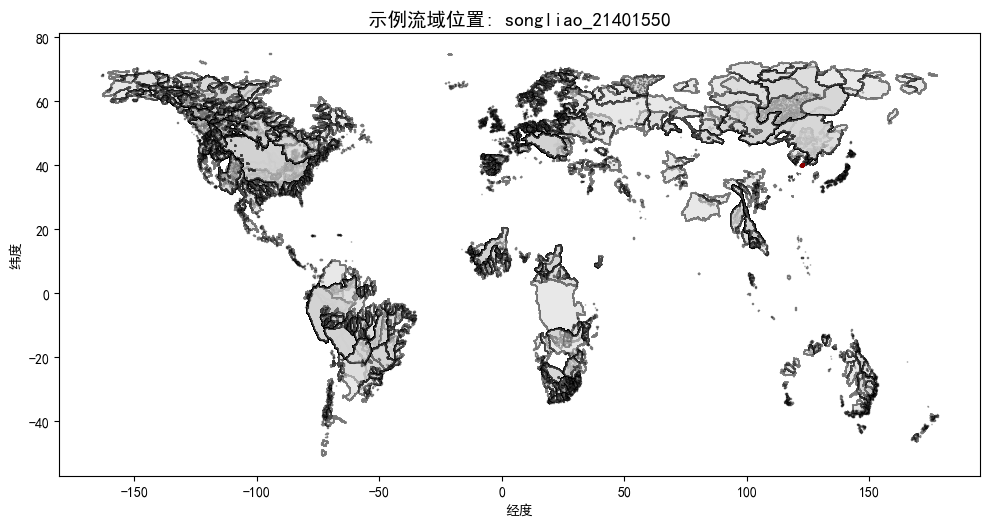

In [7]:
# 选择示例流域
example_basin_id = "songliao_21401550"

# 根据 BASIN_ID 筛选流域（字段名可能需要根据实际情况调整）
try:
    # 假设字段名为 'BASIN_ID'，如果不同请修改
    example_basin = basins_gdf[basins_gdf['BASIN_ID'] == example_basin_id]
    
    if len(example_basin) > 0:
        print(f"成功选择流域: {example_basin_id}")
        print(f"\n流域信息:")
        print(example_basin.to_string())
        
        # 获取流域边界
        basin_bounds = example_basin.total_bounds
        print(f"\n流域边界 [minx, miny, maxx, maxy]: {basin_bounds}")
        
        # 可视化流域位置
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        basins_gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
        example_basin.plot(ax=ax, color='red', edgecolor='darkred', linewidth=2)
        ax.set_title(f'示例流域位置: {example_basin_id}', fontsize=14)
        ax.set_xlabel('经度')
        ax.set_ylabel('纬度')
        plt.tight_layout()
        plt.show()
        
    else:
        print(f"错误: 未找到 BASIN_ID 为 {example_basin_id} 的流域")
        print("请检查 BASIN_ID 是否正确")
        
except KeyError as e:
    print(f"错误: 字段 {e} 不存在")
    print(f"可用字段: {list(basins_gdf.columns)}")
    print("请修改代码中的字段名")

## 5. 从 GEE 获取 GFS 降雨数据

GFS (Global Forecast System) 提供全球天气预报数据。我们将下载示例流域 2024 年的 GFS 降雨数据。

**GEE 中的 GFS 数据集**:
- 数据集 ID: `NOAA/GFS0P25` (0.25度分辨率)
- 时间分辨率: 6小时
- 变量: 降水、温度、风速等

### 5.1 获取流域单元格坐标

In [ ]:
import math

# 将 GeoPandas 的几何对象转换为 GEE 的 Geometry
def gdf_to_ee_geometry(gdf):
    """将 GeoDataFrame 转换为 Earth Engine Geometry"""
    # 转换为 GeoJSON 格式
    geojson = json.loads(gdf.to_json())
    # 获取第一个要素的几何
    coords = geojson['features'][0]['geometry']['coordinates']
    geom_type = geojson['features'][0]['geometry']['type']
    
    if geom_type == 'Polygon':
        return ee.Geometry.Polygon(coords)
    elif geom_type == 'MultiPolygon':
        return ee.Geometry.MultiPolygon(coords)
    else:
        raise ValueError(f"不支持的几何类型: {geom_type}")

# 转换示例流域为 EE Geometry
try:
    basin_geometry = gdf_to_ee_geometry(example_basin)
    print("流域几何对象转换成功！")
    print(f"流域范围: {basin_geometry.bounds().getInfo()}")
except Exception as e:
    print(f"转换几何对象时出错: {e}")


# 读取流域的外接矩形边界
bounds_poly = basin_geometry.bounds(maxError=1)  # 外接矩形
# 取 [ [minLon, minLat], [maxLon, maxLat] ]
bounds_list = bounds_poly.coordinates().get(0).getInfo()
minLon, minLat = bounds_list[0]
maxLon, maxLat = bounds_list[1]
print(f"原始外接矩形：minLon={minLon:.6f}, minLat={minLat:.6f}, maxLon={maxLon:.6f}, maxLat={maxLat:.6f}")

# 按 GFS 0.25° 网格“外扩对齐”
grid = 0.25
def floor_to_grid(x, g=grid):
    return math.floor(x / g) * g
def ceil_to_grid(x, g=grid):
    return math.ceil(x / g) * g

minLon_snap = floor_to_grid(minLon)
minLat_snap = floor_to_grid(minLat)
maxLon_snap = ceil_to_grid(maxLon)
maxLat_snap = ceil_to_grid(maxLat)

aoi = ee.Geometry.Rectangle([minLon_snap, minLat_snap, maxLon_snap, maxLat_snap], geodesic=False)

print("AOI（用于导出）坐标：", aoi.coordinates().getInfo())

流域几何对象转换成功！
流域范围: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[122.33666666173201, 39.820833341405], [122.89166666150999, 39.820833341405], [122.89166666150999, 40.33750001085514], [122.33666666173201, 40.33750001085514], [122.33666666173201, 39.820833341405]]]}
原始外接矩形：minLon=122.336667, minLat=39.820833, maxLon=122.891667, maxLat=39.820833
AOI（用于导出）坐标： [[[122.25, 39.75], [123, 39.75], [123, 40], [122.25, 40], [122.25, 39.75]]]


### 5.2 提交任务到GEE 

先定义参数和函数

In [55]:
import os, time, datetime as dt
from pathlib import Path
import ee
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive

# 用户参数
START_DATE = "2024-01-01" # 开始日期
END_DATE   = "2024-01-31" # 结束日期
LOCAL_OUT_DIR = "./gfs_tifs"
DRIVE_FOLDER  = "GFS_raw" 
SCALE_M = 25000
CRS = "EPSG:4326"

# AOI 与 band
aoi = aoi # 上一个cell获取特定流域区域
aoi_global = ee.Geometry.Rectangle([-180, -90, 180, 90], geodesic=False)  ## 全球区域
sel_bands = ["total_precipitation_surface"]

def daterange(start_date, end_date):
    start = dt.datetime.strptime(start_date, "%Y-%m-%d").date()
    end   = dt.datetime.strptime(end_date, "%Y-%m-%d").date()
    cur = start
    while cur < end:
        yield cur
        cur = cur + dt.timedelta(days=1)

def gdrive_init():
    gauth = GoogleAuth()
    gauth.LocalWebserverAuth()
    drive = GoogleDrive(gauth)
    return drive

def ensure_drive_folder(drive, folder_name):
    q = f"title = '{folder_name}' and mimeType = 'application/vnd.google-apps.folder' and trashed = false"
    fl = drive.ListFile({'q': q}).GetList()
    if fl:
        return fl[0]['id']
    folder = drive.CreateFile({'title': folder_name, 'mimeType': 'application/vnd.google-apps.folder'})
    folder.Upload()
    return folder['id']

def list_drive_file_by_name(drive, name, parent_id):
    q = f"title = '{name}' and '{parent_id}' in parents and trashed = false"
    files = drive.ListFile({'q': q}).GetList()
    return files[0] if files else None

def download_from_drive(drive, file_title, parent_id, local_path):
    f = list_drive_file_by_name(drive, file_title, parent_id)
    if not f:
        return False, f"Drive中未找到文件：{file_title}"
    Path(local_path).parent.mkdir(parents=True, exist_ok=True)
    f.GetContentFile(local_path)
    return True, f"已下载到：{local_path}"

def wait_for_tasks(tasks, poll_sec=30):
    while True:
        states = [t.status().get('state', 'UNKNOWN') for t in tasks]
        running = any(s in ('READY', 'RUNNING') for s in states)
        print("[Tasks] 状态统计：", {s: states.count(s) for s in set(states)})
        if not running:
            break
        time.sleep(poll_sec)


下载的数据保存在Google云盘，需要手动下载到本地

In [56]:
# drive = gdrive_init()
# drive_folder_id = ensure_drive_folder(drive, DRIVE_FOLDER)
# Path(LOCAL_OUT_DIR).mkdir(parents=True, exist_ok=True)

forecast_filters = [
    ee.Filter.stringContains('system:index', 'F001'),
    ee.Filter.stringContains('system:index', 'F002'),
    ee.Filter.stringContains('system:index', 'F003'),
    ee.Filter.stringContains('system:index', 'F004'),
    ee.Filter.stringContains('system:index', 'F005'),
    ee.Filter.stringContains('system:index', 'F006'),
]
combined_filter = ee.Filter.Or(*forecast_filters)

gfs = ee.ImageCollection("NOAA/GFS0P25").select(sel_bands)
gfs_filtered = gfs.filter(combined_filter)

export_tasks = []

for d in daterange(START_DATE, END_DATE):
    d0 = d.strftime("%Y-%m-%d")
    d1 = (d + dt.timedelta(days=1)).strftime("%Y-%m-%d")
    col_day = (gfs_filtered.filterDate(d0, d1).filterBounds(aoi))
    size = col_day.size().getInfo()
    if size == 0:
        print(f"[{d0}] 无影像，跳过")
        continue

    img_list = col_day.toList(size)
    merged = ee.ImageCollection(img_list).toBands()
    name = f"gfs_precip_{d.strftime('%Y%m%d')}"
    desc = f"GFS_Precip_{d.strftime('%Y%m%d')}"

    task = ee.batch.Export.image.toDrive(
        image=merged,
        description=desc,
        folder=DRIVE_FOLDER,
        fileNamePrefix=name,
        region=aoi_global,
        scale=SCALE_M,
        crs=CRS,
        maxPixels=1e13
    )
    task.start()
    export_tasks.append(task)
    print(f"[{d0}] 已提交任务：{desc}")


[2024-01-01] 已提交任务：GFS_Precip_20240101
[2024-01-02] 已提交任务：GFS_Precip_20240102
[2024-01-03] 已提交任务：GFS_Precip_20240103
[2024-01-04] 已提交任务：GFS_Precip_20240104
[2024-01-05] 已提交任务：GFS_Precip_20240105
[2024-01-06] 已提交任务：GFS_Precip_20240106
[2024-01-07] 已提交任务：GFS_Precip_20240107
[2024-01-08] 已提交任务：GFS_Precip_20240108
[2024-01-09] 已提交任务：GFS_Precip_20240109
[2024-01-10] 已提交任务：GFS_Precip_20240110
[2024-01-11] 已提交任务：GFS_Precip_20240111
[2024-01-12] 已提交任务：GFS_Precip_20240112
[2024-01-13] 已提交任务：GFS_Precip_20240113
[2024-01-14] 已提交任务：GFS_Precip_20240114
[2024-01-15] 已提交任务：GFS_Precip_20240115
[2024-01-16] 已提交任务：GFS_Precip_20240116
[2024-01-17] 已提交任务：GFS_Precip_20240117
[2024-01-18] 已提交任务：GFS_Precip_20240118
[2024-01-19] 已提交任务：GFS_Precip_20240119
[2024-01-20] 已提交任务：GFS_Precip_20240120
[2024-01-21] 已提交任务：GFS_Precip_20240121
[2024-01-22] 已提交任务：GFS_Precip_20240122
[2024-01-23] 已提交任务：GFS_Precip_20240123
[2024-01-24] 已提交任务：GFS_Precip_20240124
[2024-01-25] 已提交任务：GFS_Precip_20240125
[2024-01-26] 已提交任务：GFS_Pr

### 5.3 下载GFS数据本地

使用 `geemap` 库可以方便地下载 GEE 数据到本地。

In [ ]:
# 创建输出目录
output_dir = f"data/precipitation/{example_basin_id}"
os.makedirs(output_dir, exist_ok=True)

# 下载数据的函数
def download_ee_data_to_netcdf(image_collection, geometry, output_path, scale=1000):
    """
    从 GEE 下载数据并保存为 NetCDF 格式
    
    参数:
    - image_collection: ee.ImageCollection
    - geometry: ee.Geometry
    - output_path: 输出文件路径
    - scale: 空间分辨率(米)
    """
    try:
        # 方法1: 使用 geemap 的 ee_export_image_collection 函数
        # 这会将每个影像导出为单独的 GeoTIFF，然后可以合并
        
        # 方法2: 计算区域统计（如果只需要流域平均值）
        # 这种方法更快，适合大规模处理
        
        # 方法3: 使用 ee_to_numpy 或 ee_to_xarray（推荐用于小区域）
        # 需要 wxee 库支持
        
        print("开始下载数据...")
        print(f"输出路径: {output_path}")
        print("\n注意: 大规模数据下载可能需要较长时间")
        print("建议:")
        print("1. 使用 GEE 的 Export 功能导出到 Google Drive")
        print("2. 或者先计算流域平均值再下载（减少数据量）")
        print("3. 对于本教程，我们演示如何导出到 Google Drive")
        
        return True
        
    except Exception as e:
        print(f"下载数据时出错: {e}")
        return False

# 执行下载
output_file = os.path.join(output_dir, f"gfs_precip_2024.nc")
# download_ee_data_to_netcdf(daily_precip, basin_geometry, output_file)

### 6.可视化GFS数据


栅格大小: 265 x 114
空间范围: [-125.31498213467324, -65.80159456175494, 24.703670313286842, 50.305655910693204]
CRS: EPSG:4326


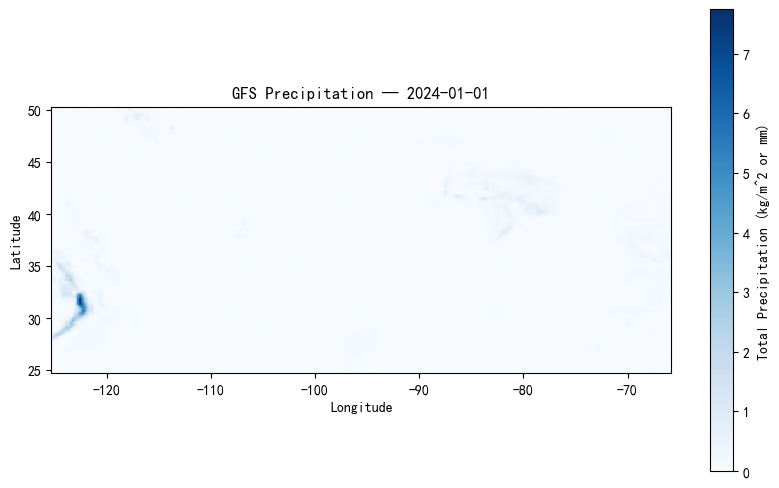

In [54]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取 GeoTIFF 文件
tif_path = "GFS_tp_daily_2024/gfs_precip_20240101.tif"
with rasterio.open(tif_path) as src:
    data = src.read(1)  # 第一波段
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    print("栅格大小:", src.width, "x", src.height)
    print("空间范围:", extent)
    print("CRS:", src.crs)

# 2. 将无效值屏蔽掉（如 GFS 中常见的填充值）
data = np.where(data < 0, np.nan, data)

# 3. 绘制降雨分布
plt.figure(figsize=(10, 6))
img = plt.imshow(data, cmap='Blues', extent=extent, origin='upper')
plt.colorbar(img, label="Total Precipitation (kg/m^2 or mm)")
plt.title("GFS Precipitation — 2024-01-01")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(False)
plt.show()


## 6. 获取 MSWEP 降雨数据

MSWEP (Multi-Source Weighted-Ensemble Precipitation) 是一个融合多源观测的降雨数据集。

MSWEP 数据为非商业用途免费提供，但通常需要先向项目组申请访问权限 ；根据 GloH2O 的官方说明，MSWEP 在其 Google Drive 共享文件夹中有提供 Daily（日积累）和 Monthly（月积累）数据，与 3 小时数据并列存放

### 第一步获取权限

GloH2O 的网站上有 “Apply Here” 的入口来获取访问 Google Drive 的共享链接和权限
收到批准之后，你就能在 Google Drive 的共享文件夹中看到 MSWEP 的各类时间尺度数据

### 第二步 使用rclone 同步下载
需要rclone配置

如果使用的是windows系统，直接下载：https://rclone.org/downloads/

打开终端测试：
```
rclone version
# 应该能看到类似的：
rclone v1.69.1
- os/version: Microsoft Windows 11 Pro 24H2 24H2 (64 bit)
- os/kernel: 10.0.26100.3476 (x86_64)
- os/type: windows
- os/arch: amd64
- go/version: go1.24.0
- go/linking: static
- go/tags: cmount
```

GloH2O 给出了用 rclone 下载的示例命令，专门排除 3 小时产品，只下载日 / 月积累文件：
```
rclone sync -v --exclude 3hourly/ --drive-shared-with-me GoogleDrive:/MSWEP_V280 c:/temp/MSWEP_V280
```
这个命令会同步共享盘 “MSWEP_V280” 下除了 “3hourly” 目录以外的所有子目录，也就包含了 Daily（和 Monthly）目录。

如果你想下载某一特定日期的数据：
```
rclone copy --drive-shared-with-me GoogleDrive:/MSWEP_V280/Past/Daily/20201106.nc ./20201106.nc
```

### 目录结构与文件命名

在 “Daily” 子目录下通常会有以年月日为命名的 NetCDF 文件，例如 2020116.nc 表示某个具体日子的降雨积累

### 从jupter服务器上下载

在我们的jupyterhub.waterism.com服务器上提供下载好的MSWEP数据，可以输入路径访问：/ftproot/mswep_3h/

其中NRT是2020-2024年的数据，而PAST文件夹是2015-2020年,后续其他年份的数据正在上传
```
ftproot/
└── mswep_3h/
    └── NRT/
        └── 3hourly/
            ├── 2020001.00.nc
            ├── 2020001.03.nc
            ├── ...
            ├── 2020330.18.nc
            ├── ...
            ├── 2024366.21.nc
            └── ... (其他2020-2024年的所有文件)

ftproot/
└── mswep_3h/
    └── PAST/
        └── 3hourly/
            ├── 2015001.00.nc
            ├── 2015001.03.nc
            ├── ...
            ├── 2020330.18.nc
            ├── ...
            ├── 2020366.21.nc
            └── ... (其他2015-2020年的所有文件)
```

## 小结

在本教程中，我们学习了：

### 完成内容
1. **环境配置**: 安装并初始化 Google Earth Engine Python API
2. **流域数据读取**: 从 shapefile 中读取 5819 个流域数据
3. **示例流域选择**: 选择 `songliao_21401550` 流域作为演示
4. **数据获取方法**: 
   -  GFS 数据
   -  MSWEP 数据
5. **数据存储**: 保存为 NetCDF 格式

### 关键要点
- **GEE 认证**: 首次使用需运行 `ee.Authenticate()`
- **数据集选择**: GEE 上公开可用的降水数据集包括 ERA5、CHIRPS等等也可以选择
- **大规模处理**: 对于多流域多年数据，建议：
  - 后续在 GEE 服务器端计算流域平均值
  - 使用批量导出任务
  - 分批处理避免超时

### 评分指标
要完成课程评分目标，你需要：
- **60分（及格）**: 完成 1 个流域 1 年数据的获取
- **60-69分（D档）**: 完成 10 流域的 10 年数据
- **70-79分（C档）**: 完成（25%+）流域的 20 年数据
- **80-89分（B档）**: 完成（50%+）流域的 20 年数据
- **90-100分（A档）**: 完成所有(5819个)流域 40 年数据，运行时间不超过一周(尝试并行计算)
